# Assignment 02 - Genetic Algorithm for TSP
**Author:** Wiktor Sosnowski, 348561

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# add src to path so modules are importable
sys.path.insert(0, '../../src/assignment_02')

from tsp_utils import load_tsplib, build_distance_matrix, tour_length
from genetic_algorithm import GeneticAlgorithm

## Load data

In [3]:
coords, city_names = load_tsplib('../../data/assignment_02/raw/berlin52.tsp')
dist_matrix = build_distance_matrix(coords)
print(f"Loaded berlin52: {len(city_names)} cities")
print(f"Known optimum: 7542")

Loaded berlin52: 52 cities
Known optimum: 7542


## Helper: run N repetitions and collect stats

In [4]:
N_RUNS = 25

def run_experiment(params: dict, n_runs: int = N_RUNS) -> dict:
    """
    Run GA n_runs times with given params.
    Returns aggregated stats and per-run histories.
    """
    lengths = []
    histories = []
    for seed in range(n_runs):
        ga = GeneticAlgorithm(dist_matrix=dist_matrix, seed=seed, **params)
        result = ga.run()
        lengths.append(result['best_length'])
        histories.append(result['history'])
    lengths = np.array(lengths)
    return {
        'min':    float(np.min(lengths)),
        'mean':   float(np.mean(lengths)),
        'std':    float(np.std(lengths)),
        'max':    float(np.max(lengths)),
        'histories': histories,
        'lengths': lengths.tolist(),
    }

def stats_row(label: str, stats: dict) -> dict:
    """Format a single result row for display."""
    return {
        'Parametr': label,
        'min':  f"{stats['min']:.2f}",
        'sr':   f"{stats['mean']:.2f}",
        'std':  f"{stats['std']:.2f}",
        'max':  f"{stats['max']:.2f}",
    }

def show_table(rows: list[dict]):
    """Display results as a DataFrame."""
    df = pd.DataFrame(rows).set_index('Parametr')
    display(df)

def plot_convergence(histories_dict: dict, title: str):
    """
    Plot mean convergence curve per parameter value.
    histories_dict: {label: list_of_histories}
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    for label, histories in histories_dict.items():
        mean_curve = np.mean(histories, axis=0)
        ax.plot(mean_curve, label=label)
    ax.axhline(7542, color='black', linestyle='--', linewidth=1, label='optimum (7542)')
    ax.set_xlabel('Generacja')
    ax.set_ylabel('Dlugos trasy')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## Baseline

**Parametry bazowe:**
- pop_size = 100
- mutation_prob = 0.01
- n_generations = 500
- selection = roulette
- tournament_size = 3 (nieaktywny w baseline)

,min,sr,std,max
Parametr,,,,
baseline,17876.00,20937.24,1048.06,22481.00


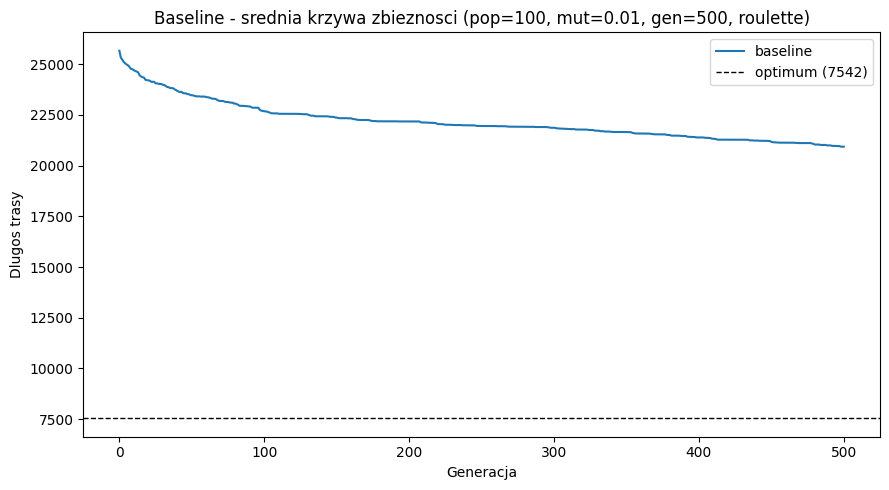

In [5]:
BASELINE_PARAMS = {
    'pop_size': 100,
    'mutation_prob': 0.01,
    'n_generations': 500,
    'selection': 'roulette',
    'tournament_size': 3,
}

baseline_stats = run_experiment(BASELINE_PARAMS)
show_table([stats_row('baseline', baseline_stats)])
plot_convergence({'baseline': baseline_stats['histories']},
                 'Baseline - srednia krzywa zbieznosci (pop=100, mut=0.01, gen=500, roulette)')

---
## Eksperyment 1: Rozmiar populacji

**Stale parametry:** mutation_prob=0.01, n_generations=500, selection=roulette  
**Badany zakres:** pop_size in [20, 50, 100, 200, 500]

pop_size=20 done
pop_size=50 done
pop_size=100 done
pop_size=200 done
pop_size=500 done
pop_size=1000 done
pop_size=2000 done


,min,sr,std,max
Parametr,,,,
pop_size=20,22158.00,24580.00,956.84,26262.00
pop_size=50,19776.00,22290.64,1080.27,25053.00
pop_size=100,17876.00,20937.24,1048.06,22481.00
pop_size=200,17963.00,19702.44,1001.07,21496.00
pop_size=500,16920.00,19629.24,920.07,21084.00
pop_size=1000,17693.00,19247.20,781.75,20612.00
pop_size=2000,15097.00,18710.24,1080.44,20118.00


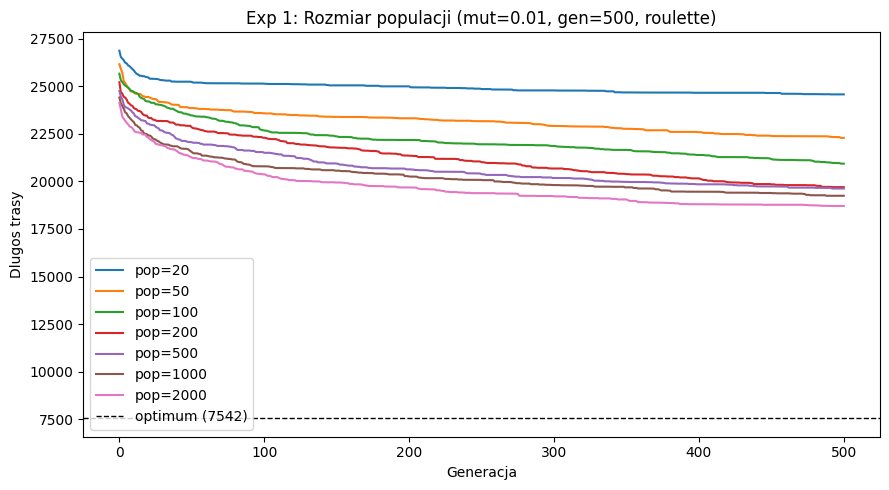

In [11]:
pop_sizes = [20, 50, 100, 200, 500, 1000, 2000]
exp1_results = {}
exp1_rows = []

for ps in pop_sizes:
    params = {**BASELINE_PARAMS, 'pop_size': ps}
    stats = run_experiment(params)
    exp1_results[f'pop={ps}'] = stats
    exp1_rows.append(stats_row(f'pop_size={ps}', stats))
    print(f'pop_size={ps} done')

show_table(exp1_rows)
plot_convergence(
    {k: v['histories'] for k, v in exp1_results.items()},
    'Exp 1: Rozmiar populacji (mut=0.01, gen=500, roulette)'
)

---
## Eksperyment 2: Prawdopodobienstwo mutacji

**Stale parametry:** pop_size=100, n_generations=500, selection=roulette  
**Badany zakres:** mutation_prob in [0.001, 0.01, 0.05, 0.1, 0.3]

mutation_prob=0.001 done
mutation_prob=0.003 done
mutation_prob=0.005 done
mutation_prob=0.007 done
mutation_prob=0.01 done
mutation_prob=0.05 done
mutation_prob=0.1 done
mutation_prob=0.3 done


,min,sr,std,max
Parametr,,,,
mutation_prob=0.001,20871.00,22498.12,961.11,24610.00
mutation_prob=0.003,19303.00,21660.84,1385.32,24203.00
mutation_prob=0.005,18653.00,21823.20,1244.03,23962.00
mutation_prob=0.007,18986.00,21403.84,1278.96,23646.00
mutation_prob=0.01,17876.00,20937.24,1048.06,22481.00
mutation_prob=0.05,20111.00,21446.00,799.25,23299.00
mutation_prob=0.1,19843.00,21354.32,821.29,22897.00
mutation_prob=0.3,19387.00,21738.32,750.77,23199.00


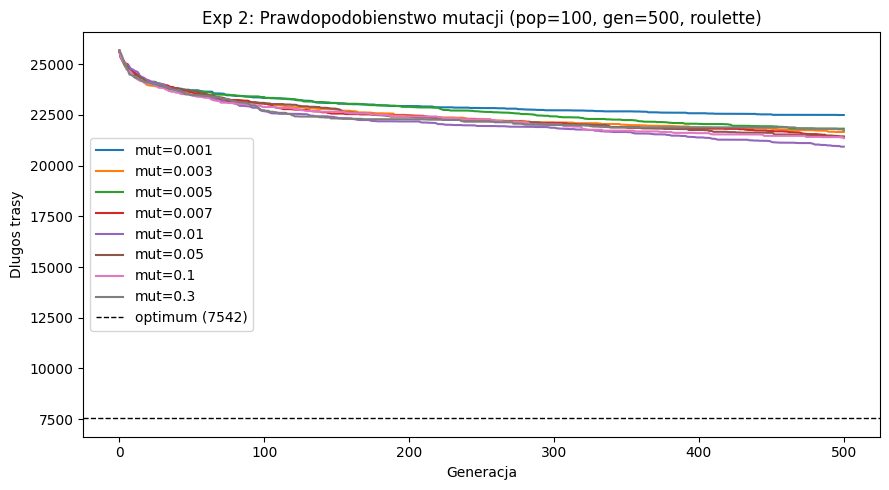

In [12]:
mut_probs = [0.001, 0.003, 0.005, 0.007, 0.01, 0.05, 0.1, 0.3]
exp2_results = {}
exp2_rows = []

for mp in mut_probs:
    params = {**BASELINE_PARAMS, 'mutation_prob': mp}
    stats = run_experiment(params)
    exp2_results[f'mut={mp}'] = stats
    exp2_rows.append(stats_row(f'mutation_prob={mp}', stats))
    print(f'mutation_prob={mp} done')

show_table(exp2_rows)
plot_convergence(
    {k: v['histories'] for k, v in exp2_results.items()},
    'Exp 2: Prawdopodobienstwo mutacji (pop=100, gen=500, roulette)'
)

---
## Eksperyment 3: Selekcja turniejowa vs ruletkowa

**Stale parametry:** pop_size=100, mutation_prob=0.01, n_generations=500  
**Badane warianty:** selection in [roulette, tournament], tournament_size in [2, 3, 5, 10] dla turniejowej

roulette done
tournament k=2 done
tournament k=3 done
tournament k=5 done
tournament k=10 done


,min,sr,std,max
Parametr,,,,
roulette,17876.00,20937.24,1048.06,22481.00
tournament (k=2),13034.00,14443.84,949.16,16322.00
tournament (k=3),12028.00,13655.16,860.98,15168.00
tournament (k=5),11781.00,13632.20,792.04,15078.00
tournament (k=10),12447.00,13831.16,704.40,15659.00


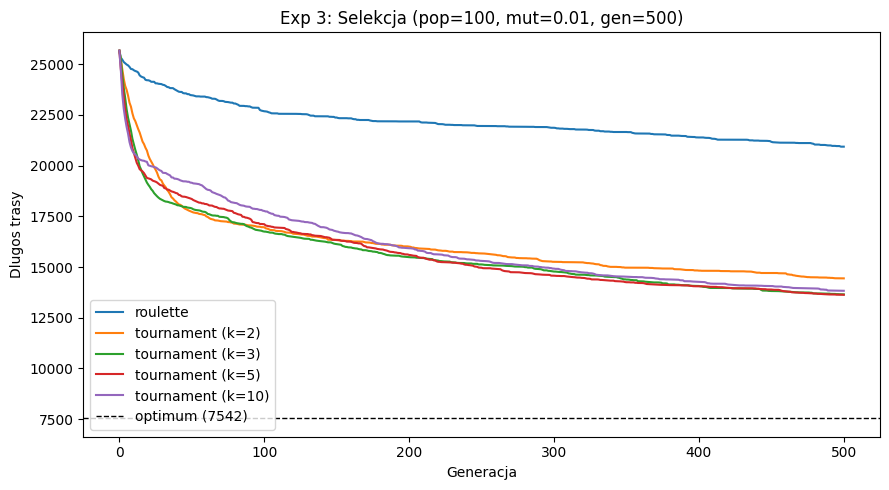

In [13]:
exp3_results = {}
exp3_rows = []

# roulette - reference
stats = run_experiment(BASELINE_PARAMS)
exp3_results['roulette'] = stats
exp3_rows.append(stats_row('roulette', stats))
print('roulette done')

# tournament with varying tournament size
for ts in [2, 3, 5, 10]:
    params = {**BASELINE_PARAMS, 'selection': 'tournament', 'tournament_size': ts}
    stats = run_experiment(params)
    label = f'tournament (k={ts})'
    exp3_results[label] = stats
    exp3_rows.append(stats_row(label, stats))
    print(f'tournament k={ts} done')

show_table(exp3_rows)
plot_convergence(
    {k: v['histories'] for k, v in exp3_results.items()},
    'Exp 3: Selekcja (pop=100, mut=0.01, gen=500)'
)

---
## Zapis wynikow zbiorczych

In [14]:
import os
os.makedirs('../../results/assignment_02', exist_ok=True)

# collect all results (without histories to keep file small)
def strip_histories(stats: dict) -> dict:
    return {k: v for k, v in stats.items() if k not in ('histories', 'lengths')}

all_results = {
    'baseline': strip_histories(baseline_stats),
    'exp1_pop_size': {
        f'pop_size={ps}': strip_histories(exp1_results[f'pop={ps}'])
        for ps in pop_sizes
    },
    'exp2_mutation_prob': {
        f'mutation_prob={mp}': strip_histories(exp2_results[f'mut={mp}'])
        for mp in mut_probs
    },
    'exp3_selection': {
        label: strip_histories(exp3_results[label])
        for label in exp3_results
    },
}

with open('../../results/assignment_02/results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print('Saved: results/assignment_02/results.json')

Saved: results/assignment_02/results.json


In [15]:
# save all raw per-run lengths as CSV for traceability
import csv

rows_csv = []

rows_csv.append({'experiment': 'baseline', 'variant': 'baseline',
                 **{f'run_{i}': v for i, v in enumerate(baseline_stats['lengths'])}})

for ps in pop_sizes:
    s = exp1_results[f'pop={ps}']
    rows_csv.append({'experiment': 'exp1_pop_size', 'variant': f'pop_size={ps}',
                     **{f'run_{i}': v for i, v in enumerate(s['lengths'])}})

for mp in mut_probs:
    s = exp2_results[f'mut={mp}']
    rows_csv.append({'experiment': 'exp2_mutation_prob', 'variant': f'mutation_prob={mp}',
                     **{f'run_{i}': v for i, v in enumerate(s['lengths'])}})

for label in exp3_results:
    s = exp3_results[label]
    rows_csv.append({'experiment': 'exp3_selection', 'variant': label,
                     **{f'run_{i}': v for i, v in enumerate(s['lengths'])}})

df_all = pd.DataFrame(rows_csv)
df_all.to_csv('../../results/assignment_02/raw_lengths.csv', index=False)
print('Saved: results/assignment_02/raw_lengths.csv')

Saved: results/assignment_02/raw_lengths.csv
